## M3 MobileNetV2 LSTM

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0))/1024**3:.2f} GiB")

GPU free: 10.90 GiB


In [2]:
import os, gc, time, csv, cv2
os.environ["KERAS_BACKEND"]              = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]    = "expandable_segments:True"

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import keras
from keras import layers, optimizers

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project/data")
FRAMES_DIR = DATA_DIR / "UCF50_frames"
DATASET_DIR = DATA_DIR / "UCF50"

# ── Config ────────────────────────────────────────────────────────────────────
IMG_HEIGHT      = 64
IMG_WIDTH       = 64
SEQUENCE_LENGTH = 16
BATCH_SIZE      = 4
EPOCHS          = 20
LEARNING_RATE   = 1e-4
NUM_CLASSES     = 50

# ── Class mapping ─────────────────────────────────────────────────────────────
CLASS_NAMES_SORTED = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
class_to_idx       = {cls: idx for idx, cls in enumerate(CLASS_NAMES_SORTED)}
idx_to_class       = {idx: cls for cls, idx in class_to_idx.items()}

print(f"✅ Keras backend : {keras.backend.backend()}")
print(f"✅ Device        : {DEVICE}")
print(f"✅ Classes       : {len(class_to_idx)}")
print(f"✅ Frames dir    : {FRAMES_DIR.exists()}")

✅ Keras backend : torch
✅ Device        : cuda
✅ Classes       : 50
✅ Frames dir    : True


In [3]:
class PreextractedDataset(Dataset):
    """Loads pre-extracted .npy frame arrays — fast, no video I/O during training."""
    def __init__(self, frames_dir, split, class_to_idx):
        self.samples = []
        for class_dir in sorted((Path(frames_dir) / split).iterdir()):
            if not class_dir.is_dir():
                continue
            label = class_to_idx[class_dir.name]
            for npy_path in sorted(class_dir.glob("*.npy")):
                self.samples.append((str(npy_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        frames = np.load(npy_path)  # (16, 112, 112, 3)
        
        # Resize to target resolution if needed
        if frames.shape[1] != IMG_HEIGHT:
            frames = np.stack([
                cv2.resize(f, (IMG_WIDTH, IMG_HEIGHT)) for f in frames
            ])
        
        frames = torch.tensor(frames).permute(3, 0, 1, 2).float()
        return frames, torch.tensor(label, dtype=torch.long)


train_dataset = PreextractedDataset(FRAMES_DIR, "train", class_to_idx)
val_dataset   = PreextractedDataset(FRAMES_DIR, "val",   class_to_idx)
test_dataset  = PreextractedDataset(FRAMES_DIR, "test",  class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"✅ Train : {len(train_dataset):,} videos → {len(train_loader)} steps/epoch")
print(f"✅ Val   : {len(val_dataset):,} videos → {len(val_loader)} steps/epoch")
print(f"✅ Test  : {len(test_dataset):,} videos → {len(test_loader)} steps/epoch")

# ── Quick shape check ─────────────────────────────────────────────────────────
sample_frames, sample_labels = next(iter(train_loader))
print(f"\nBatch frames : {sample_frames.shape}  → (B, C, T, H, W)")
print(f"Batch labels : {sample_labels.shape}  dtype={sample_labels.dtype}")

✅ Train : 5,288 videos → 1322 steps/epoch
✅ Val   : 640 videos → 160 steps/epoch
✅ Test  : 698 videos → 175 steps/epoch

Batch frames : torch.Size([4, 3, 16, 64, 64])  → (B, C, T, H, W)
Batch labels : torch.Size([4])  dtype=torch.int64


In [4]:
def train_model_keras(model, model_name, train_loader, val_loader, epochs=EPOCHS):
    """
    Training loop for Keras (torch backend) with PyTorch DataLoader.
    Features: per-batch cache clearing, early stopping (patience=5),
    checkpointing, CSV history logging, flush=True for real-time output.
    """
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory reserved: {torch.cuda.memory_reserved()/1024**3:.2f} GiB", flush=True)

    model.compile(
        optimizer = optimizers.Adam(learning_rate=LEARNING_RATE),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    best_val_loss  = float("inf")
    patience_count = 0
    patience       = 5
    history        = []

    print(f"\n{'='*60}", flush=True)
    print(f"Training: {model_name}", flush=True)
    print(f"{'='*60}", flush=True)

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── Training ──────────────────────────────────────────────────────────
        train_losses, train_accs = [], []
        for batch_idx, (frames, labels) in enumerate(train_loader):
            frames_np = frames.permute(0, 2, 3, 4, 1).numpy()
            labels_np = labels.numpy()
            metrics   = model.train_on_batch(frames_np, labels_np)
            train_losses.append(metrics[0])
            train_accs.append(metrics[1])

            # Clear cache every 50 batches to prevent fragmentation
            if (batch_idx + 1) % 50 == 0:
                torch.cuda.empty_cache()

            if (batch_idx + 1) % 100 == 0:
                print(f"  Epoch {epoch} | Batch {batch_idx+1}/{len(train_loader)} | "
                      f"loss: {metrics[0]:.4f}  acc: {metrics[1]:.4f}", flush=True)

        # ── Validation ────────────────────────────────────────────────────────
        val_losses, val_accs = [], []
        for frames, labels in val_loader:
            frames_np = frames.permute(0, 2, 3, 4, 1).numpy()
            labels_np = labels.numpy()
            metrics   = model.test_on_batch(frames_np, labels_np)
            val_losses.append(metrics[0])
            val_accs.append(metrics[1])

        train_loss = sum(train_losses) / len(train_losses)
        train_acc  = sum(train_accs)  / len(train_accs)
        val_loss   = sum(val_losses)  / len(val_losses)
        val_acc    = sum(val_accs)    / len(val_accs)
        elapsed    = time.time() - t0

        history.append({
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc
        })

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f} | "
              f"{elapsed:.1f}s", flush=True)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            model.save(f"best_{model_name}.keras")
            print(f"  💾 Saved best model (val_loss: {best_val_loss:.4f})", flush=True)
            patience_count = 0
        else:
            patience_count += 1
            print(f"  ⏳ No improvement ({patience_count}/{patience})", flush=True)
            if patience_count >= patience:
                print(f"\nEarly stopping at epoch {epoch}.", flush=True)
                break

    # Save history to CSV
    with open(f"history_{model_name}.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)

    print(f"\n✅ Training complete. Best val_loss: {best_val_loss:.4f}", flush=True)
    return model, history

print("✅ Training loop ready")

✅ Training loop ready


### Model Definition

In [5]:
# ── M3: MobileNetV2 + LSTM ───────────────────────────────────────────────────
backbone = keras.applications.MobileNetV2(
    input_shape = (IMG_HEIGHT, IMG_WIDTH, 3),
    include_top = False,
    weights     = "imagenet",
    pooling     = "avg"
)
backbone.trainable = False  # freeze pretrained weights

inputs = keras.Input(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3))
x = layers.TimeDistributed(backbone)(inputs)   # (B, T, 1280)
x = layers.LSTM(128, return_sequences=False)(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_LSTM")
trainable = sum(1 for w in model.trainable_weights)
total     = sum(1 for w in model.weights)
print(f"Trainable weight tensors : {trainable} / {total}")
model.summary()

/tmp/ipykernel_242795/1571467019.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weight tensors : 7 / 267


Model: "MobileNetV2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 64, 64, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,025,266 (11.54 MB)

 Trainable params: 767,282 (2.93 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training

In [6]:
model, history = train_model_keras(model, "MobileNetV2_LSTM", train_loader, val_loader)

GPU memory reserved: 0.03 GiB

Training: MobileNetV2_LSTM


/home/msds2026/fcapati/.conda/envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


  Epoch 1 | Batch 100/1322 | loss: 3.9019  acc: 0.0250
  Epoch 1 | Batch 200/1322 | loss: 3.8410  acc: 0.0562
  Epoch 1 | Batch 300/1322 | loss: 3.7852  acc: 0.0950
  Epoch 1 | Batch 400/1322 | loss: 3.7241  acc: 0.1181
  Epoch 1 | Batch 500/1322 | loss: 3.6555  acc: 0.1430
  Epoch 1 | Batch 600/1322 | loss: 3.5932  acc: 0.1637
  Epoch 1 | Batch 700/1322 | loss: 3.5089  acc: 0.1893
  Epoch 1 | Batch 800/1322 | loss: 3.4375  acc: 0.2100
  Epoch 1 | Batch 900/1322 | loss: 3.3596  acc: 0.2314
  Epoch 1 | Batch 1000/1322 | loss: 3.2875  acc: 0.2480
  Epoch 1 | Batch 1100/1322 | loss: 3.2118  acc: 0.2659
  Epoch 1 | Batch 1200/1322 | loss: 3.1386  acc: 0.2812
  Epoch 1 | Batch 1300/1322 | loss: 3.0684  acc: 0.2948
Epoch 01/20 | train_loss: 3.5260  train_acc: 0.1701 | val_loss: 2.9915  val_acc: 0.3137 | 2430.1s
  💾 Saved best model (val_loss: 2.9915)
  Epoch 2 | Batch 100/1322 | loss: 2.8822  acc: 0.3401
  Epoch 2 | Batch 200/1322 | loss: 2.8177  acc: 0.3554
  Epoch 2 | Batch 300/1322 | loss

**Note**

*Why MobileNetV2?*
  
MobileNetV2 is a lightweight convolutional neural network pre-trained on ImageNet — a large-scale dataset of 1.2 million images across 1,000 object categories. Through this pre-training, the network learned rich hierarchical visual representations, from low-level features such as edges and textures to mid-level features such as shapes and body parts. While ImageNet contains no action recognition categories, these learned features transfer well to video-based activity recognition, where identifying human body postures and motion-relevant spatial patterns is critical.

MobileNetV2 was selected over heavier alternatives (e.g. VGG16, ResNet50) for three practical reasons: it is computationally lightweight and fits within the GPU memory budget of our training environment; it produces a rich 1,280-dimensional feature vector per frame despite its compact size; and it is natively available via keras.applications, requiring no additional setup.

*What is frozen and why?*
    
MobileNetV2's convolutional feature extractor is frozen (backbone.trainable = False) during training, meaning its weights are locked and receive no gradient updates. Only the LSTM and classification head are trained. This design choice serves three purposes. First, the pretrained convolutional weights already encode strong visual representations developed over extensive ImageNet training — updating them on our relatively small UCF50 subset risks overwriting these features with noisier, task-specific ones. Second, freezing prevents catastrophic forgetting, where fine-tuning on a small dataset causes the network to lose its generalizable representations. Third, frozen layers do not require gradient computation, significantly reducing GPU memory usage — an important practical constraint given our shared server environment.

In effect, MobileNetV2 acts as a fixed spatial feature extractor, transforming each of the 16 sampled frames into a 1,280-dimensional feature vector. These vectors are then passed as a temporal sequence to the LSTM, which models how the spatial features evolve over time to produce the final activity classification.

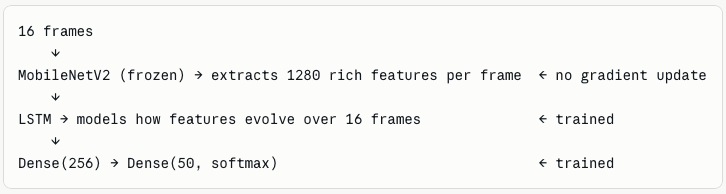